# Detailed HH population drives three reduction models

这个例子使用 10 个依次放电的 HH Cell，同时驱动三个各含 3 个 Cell 的约化 population。三个下游 Cell 拥有完全相同的 morphology、10 个 CV 和异构 synapse 分布，分别展示三层输入语义：

1. `EventAccumulatorReduction` 只判断 synapse slot 是否收到 event。
2. `PayloadAccumulatorReduction` 累加 connection 送达的真实 payload 幅值。
3. `SynapticKernelAccumulatorReduction` 读取 synapse 类型及时间常数，把完整 conductance kernel 静态折算为面积。

三者都不会推进 detailed Cell 的膜、离子、通道或真实 synapse 动力学。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import braincell
import brainunit as u
from braincell import mech
from braincell.filter import AllRegion, at

HH_SIZE = 10
REDUCTION_SIZE = 3
DT = 0.025 * u.ms
DURATION = 25.0 * u.ms
CONNECTION_DELAY = 0.1 * u.ms
SOURCE_WEIGHTS = np.arange(1, HH_SIZE + 1) * 0.02 * u.uS
EVENT_ALPHA = np.asarray([0.9, 0.99, 1.0])
EVENT_THRESHOLD = 15.0
PAYLOAD_THRESHOLDS = np.asarray([0.3, 0.7, 1.0]) * u.uS
KERNEL_ALPHA = 0.99
KERNEL_THRESHOLD = 8.0 * u.uS * u.ms


def build_reduction_morphology():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma"
    )
    dend_a = braincell.Branch.from_lengths(
        lengths=[160.0] * u.um, radii=[2.0, 1.0] * u.um, type="basal_dendrite"
    )
    dend_b = braincell.Branch.from_lengths(
        lengths=[220.0] * u.um, radii=[2.5, 0.8] * u.um, type="apical_dendrite"
    )
    morphology = braincell.Morphology.from_root(soma, name="soma")
    morphology.soma.dend_a = dend_a
    morphology.soma.dend_b = dend_b
    return morphology


def build_hh_population():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma"
    )
    cell = braincell.Cell(
        braincell.Morphology.from_root(soma, name="soma"),
        cv_policy=braincell.CVPerBranch(),
        pop_size=(HH_SIZE,),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        name="hh",
    )
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-54.3 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        mech.Ion("SodiumFixed", E=50.0 * u.mV),
        mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        mech.Channel("IL", name="leak", g_max=0.3 * u.mS / u.cm**2, E=-54.3 * u.mV),
        mech.Channel("Na_HH1952", name="na", g_max=120.0 * u.mS / u.cm**2),
        mech.Channel("K_HH1952", name="k", g_max=36.0 * u.mS / u.cm**2),
    )
    cell.place(
        at("soma", 0.5),
        mech.CurrentClamp(
            delay=(2.0 + np.arange(HH_SIZE)) * u.ms,
            durations=1.0 * u.ms,
            amplitudes=1.0 * u.nA,
        ),
    )
    return cell


SYNAPSE_LOCATIONS = (
    at("dend_a", 0.2) | at("dend_a", 0.5) | at("dend_a", 0.8)
    | at("dend_b", 0.2) | at("dend_b", 0.5) | at("dend_b", 0.8)
)


def build_reduction_population(name, selected_model):
    cell = braincell.Cell(
        build_reduction_morphology(),
        cv_policy=braincell.CVPerBranchList((1, 4, 5)),
        pop_size=(REDUCTION_SIZE,),
        name=name,
    )
    cell[0].place(
        SYNAPSE_LOCATIONS,
        mech.Synapse("ExpSyn", name="exp_tau_1", tau=1.0 * u.ms),
    )
    cell[1].place(
        SYNAPSE_LOCATIONS,
        mech.Synapse("ExpSyn", name="exp_tau_4", tau=4.0 * u.ms),
    )
    cell[2].place(
        SYNAPSE_LOCATIONS,
        mech.Synapse("Exp2Syn", name="exp2", tau1=0.5 * u.ms, tau2=5.0 * u.ms),
    )
    cell.add_reduction(
        "event", braincell.EventAccumulatorReduction(alpha=0.9, threshold=EVENT_THRESHOLD)
    )
    cell.add_reduction(
        "payload", braincell.PayloadAccumulatorReduction(threshold=0.3 * u.uS)
    )
    cell.add_reduction(
        "kernel",
        braincell.SynapticKernelAccumulatorReduction(
            alpha=KERNEL_ALPHA, threshold=KERNEL_THRESHOLD
        ),
    )
    cell.reductions["event"].set(alpha=EVENT_ALPHA, threshold=EVENT_THRESHOLD)
    cell.reductions["payload"].set(alpha=0.0, threshold=PAYLOAD_THRESHOLDS)
    cell.reductions["kernel"].set(alpha=KERNEL_ALPHA, threshold=KERNEL_THRESHOLD)
    cell.use_model(selected_model)
    cell.record("value", braincell.observe.output("value"))
    return cell

## Shared network input

每种 synapse name/type 必须通过独立的 `connect()` 建立连接。每个 HH source 仍会连接到某个目标 population 的全部 18 个逻辑 synapse，所以每组 reduction population 合计有 $10 \times 18 = 180$ 条 Connection。

In [2]:
network = braincell.Network("hh_to_reductions")
hh = network.add_population("hh", build_hh_population())
event = network.add_population(
    "event", build_reduction_population("event_cell", "event")
)
payload = network.add_population(
    "payload", build_reduction_population("payload_cell", "payload")
)
kernel = network.add_population(
    "kernel", build_reduction_population("kernel_cell", "kernel")
)


def connect_all_to_all(prefix, source, target):
    connections = []
    synapse_names = tuple(dict.fromkeys(target.synapses.name.tolist()))
    for synapse_name in synapse_names:
        synapses = target.synapses[synapse_name]
        source_position = np.repeat(np.arange(source.size), len(synapses))
        synapse_position = np.tile(np.arange(len(synapses)), source.size)
        connections.append(
            network.connect(
                f"{prefix}_{synapse_name}",
                source=source.event_outputs["spike"][source_position],
                synapse=synapses[synapse_position],
                weight=SOURCE_WEIGHTS[source_position],
                delay=CONNECTION_DELAY,
            )
        )
    return tuple(connections)


connection_groups = {
    name: connect_all_to_all(f"hh_to_{name}", hh, population)
    for name, population in (("event", event), ("payload", payload), ("kernel", kernel))
}
structure = pd.DataFrame(
    {
        "population": ["hh", "event", "payload", "kernel"],
        "members": [hh.size, event.size, payload.size, kernel.size],
        "CVs per member": [hh.cell.n_cv, event.cell.n_cv, payload.cell.n_cv, kernel.cell.n_cv],
        "synapses": [0, len(event.synapses), len(payload.synapses), len(kernel.synapses)],
        "incoming connections": [
            0,
            sum(map(len, connection_groups["event"])),
            sum(map(len, connection_groups["payload"])),
            sum(map(len, connection_groups["kernel"])),
        ],
    }
)
display(structure)

result = network.run(dt=DT, duration=DURATION)
time_ms = np.asarray(result.time.to_decimal(u.ms))
event_frames = []
for population_name in ("hh", "event", "payload", "kernel"):
    events = result.events[population_name]["spike"]
    event_frames.append(
        pd.DataFrame(
            {
                "population": population_name,
                "time_ms": np.asarray(events.time.to_decimal(u.ms)),
                "source_id": events.source_id,
                "count": events.count,
            }
        )
    )
spike_table = pd.concat(event_frames, ignore_index=True)
display(spike_table.groupby("population", sort=False).size().rename("spike records").to_frame())

hh_spike_times_ms = np.asarray(result.events["hh"]["spike"].time.to_decimal(u.ms))
arrival_times_ms = hh_spike_times_ms + float(CONNECTION_DELAY.to_decimal(u.ms))
arrival_rows = np.asarray([np.argmin(np.abs(time_ms - value)) for value in arrival_times_ms])

,population,members,CVs per member,synapses,incoming connections
0,hh,10,1,0,0
1,event,3,10,18,180
2,payload,3,10,18,180
3,kernel,3,10,18,180


,spike records
population,
hh,10
event,5
payload,15
kernel,4


## Event accumulator: presence only

三个 member 使用相同阈值 `15`，只改变 `alpha`。圆点表示输入到达时的 candidate value，叉号表示越过阈值时发出的 spike。虽然 source weight 不断增加，这个模型在每次到达时仍只看到 6 个活动 slot。

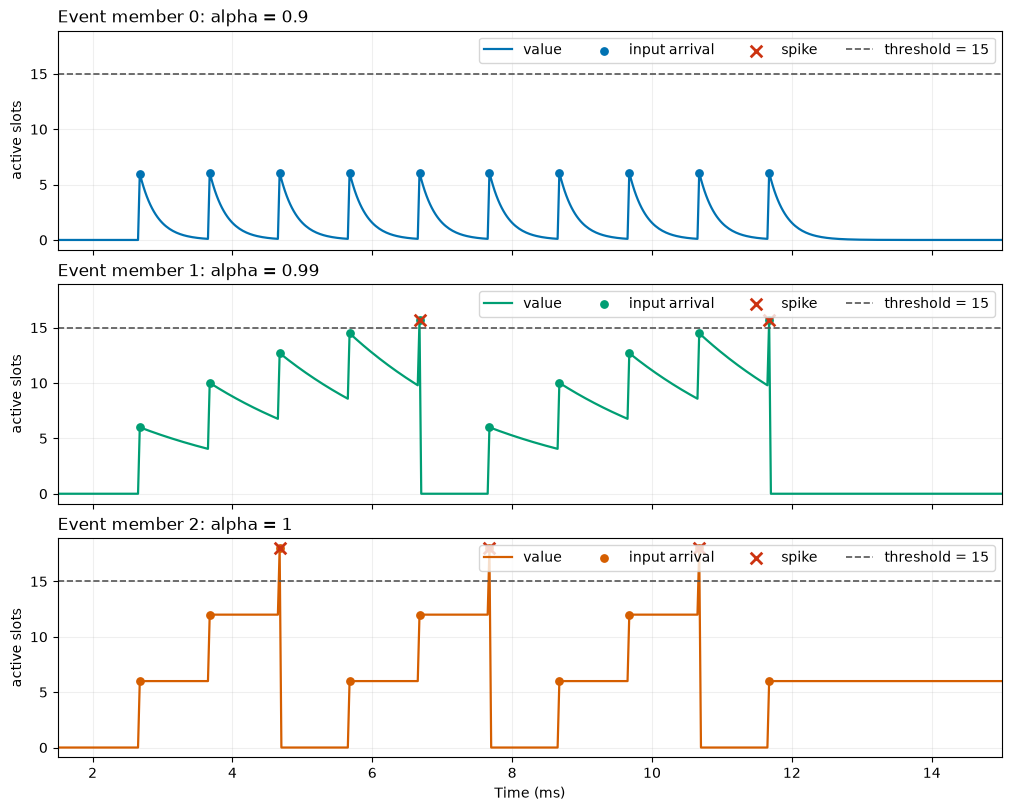

In [3]:
def plot_accumulator(population_name, values, parameters, threshold, y_label, titles):
    events = result.events[population_name]["spike"]
    event_times = np.asarray(events.time.to_decimal(u.ms))
    event_ids = np.asarray(events.source_id)
    colors = ("#0072B2", "#009E73", "#D55E00")
    fig, axes = plt.subplots(
        REDUCTION_SIZE, 1, figsize=(10, 8), sharex=True, sharey=True, constrained_layout=True
    )
    for member, (axis, color) in enumerate(zip(axes, colors)):
        axis.plot(time_ms, values[:, member], color=color, linewidth=1.6, label="value")
        axis.scatter(
            arrival_times_ms, values[arrival_rows, member], color=color, s=28, zorder=3, label="input arrival"
        )
        member_spikes = event_times[event_ids == member]
        spike_rows = [np.argmin(np.abs(time_ms - value)) for value in member_spikes]
        axis.scatter(
            member_spikes, values[spike_rows, member], color="#CC3311", marker="x",
            s=70, linewidths=2, zorder=4, label="spike"
        )
        member_threshold = threshold[member] if getattr(threshold, "shape", ()) else threshold
        axis.axhline(
            member_threshold, color="#555555", linestyle="--", linewidth=1.2,
            label=f"threshold = {member_threshold:g}"
        )
        axis.set_title(titles[member], loc="left")
        axis.set_ylabel(y_label)
        axis.grid(alpha=0.2)
        axis.legend(loc="upper right", ncols=4)
    axes[-1].set_xlabel("Time (ms)")
    axes[-1].set_xlim(1.5, 15.0)
    plt.show()


event_value = np.asarray(result.samples["event"]["value"].values)
plot_accumulator(
    "event",
    event_value,
    EVENT_ALPHA,
    np.full(REDUCTION_SIZE, EVENT_THRESHOLD),
    "active slots",
    [f"Event member {member}: alpha = {alpha:g}" for member, alpha in enumerate(EVENT_ALPHA)],
)

## Payload accumulator: physical amplitude

Payload 模型设置 `alpha=0`，因此只显示当前时刻的输入幅值。三个 member 收到相同的 `6 × source weight`，但使用不同的 `uS` 阈值；synapse 类型和 tau 不参与计算。

In [4]:
payload_value_us = result.samples["payload"]["value"].values.to_decimal(u.uS)
pd.DataFrame(
    {
        "HH source": np.asarray(result.events["hh"]["spike"].source_id),
        "arrival time (ms)": arrival_times_ms,
        "source weight (uS)": SOURCE_WEIGHTS.to_decimal(u.uS),
        "member 0 value (threshold 0.3 uS)": payload_value_us[arrival_rows, 0],
        "member 1 value (threshold 0.7 uS)": payload_value_us[arrival_rows, 1],
        "member 2 value (threshold 1.0 uS)": payload_value_us[arrival_rows, 2],
    }
)

,HH source,arrival time (ms),source weight (uS),member 0 value (threshold 0.3 uS),member 1 value (threshold 0.7 uS),member 2 value (threshold 1.0 uS)
0,0,2.675,0.02,0.12,0.12,0.12
1,1,3.675,0.04,0.24,0.24,0.24
2,2,4.675,0.06,0.36,0.36,0.36
3,3,5.675,0.08,0.48,0.48,0.48
4,4,6.675,0.10,0.60,0.60,0.60
5,5,7.675,0.12,0.72,0.72,0.72
6,6,8.675,0.14,0.84,0.84,0.84
7,7,9.675,0.16,0.96,0.96,0.96
8,8,10.675,0.18,1.08,1.08,1.08
9,9,11.675,0.20,1.20,1.20,1.20


## Synaptic kernel accumulator: static metadata-aware area

Kernel 模型不会创建 `ExpSyn.g` 或 `Exp2Syn.A/B`。它在初始化时读取类型和时间常数：单指数的单位权重面积是 `tau`；双指数的单位权重面积是 `factor × (tau2 - tau1)`，其中 factor 保证 kernel 的峰值为 1。三者使用相同 `alpha=0.99` 和阈值 `8 uS·ms`。

,member,synapse declaration,kernel area / unit weight (ms)
0,0,6 x ExpSyn(tau=1 ms),1.000000
1,1,6 x ExpSyn(tau=4 ms),4.000000
2,2,"6 x Exp2Syn(tau1=0.5 ms, tau2=5 ms)",6.457748


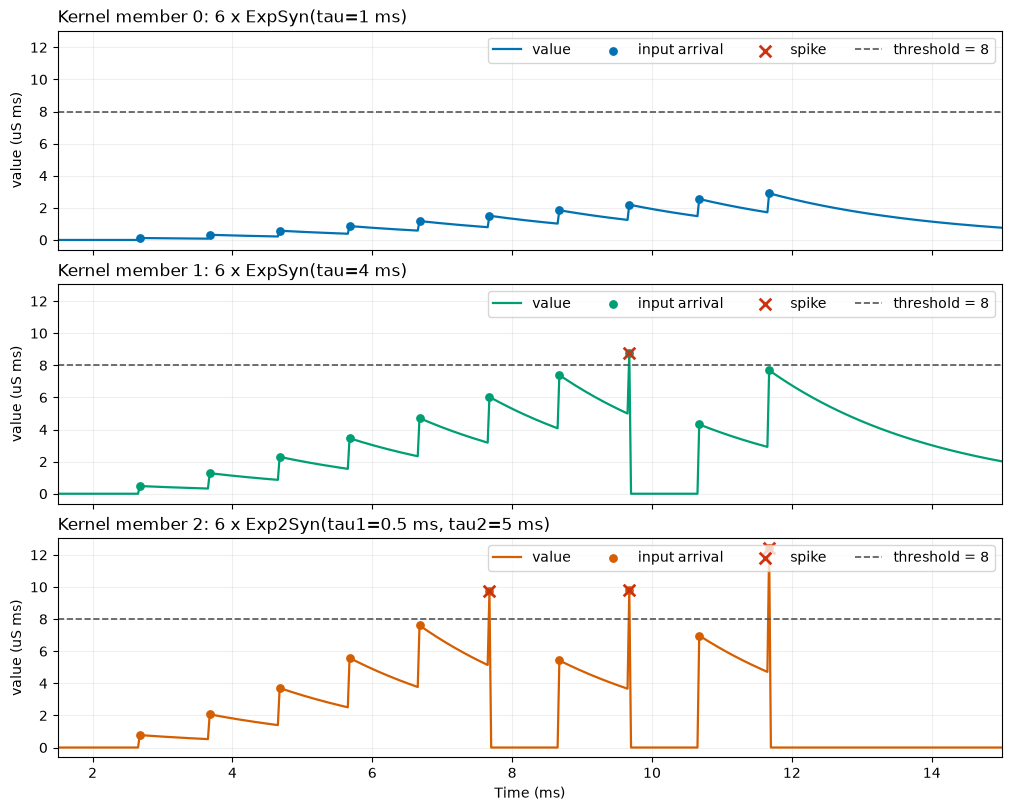

In [5]:
tau1_ms = 0.5
tau2_ms = 5.0
t_peak_ms = tau1_ms * tau2_ms / (tau2_ms - tau1_ms) * np.log(tau2_ms / tau1_ms)
exp2_factor = 1.0 / (np.exp(-t_peak_ms / tau2_ms) - np.exp(-t_peak_ms / tau1_ms))
kernel_area_ms = np.asarray([1.0, 4.0, exp2_factor * (tau2_ms - tau1_ms)])
kernel_labels = (
    "6 x ExpSyn(tau=1 ms)",
    "6 x ExpSyn(tau=4 ms)",
    "6 x Exp2Syn(tau1=0.5 ms, tau2=5 ms)",
)
display(
    pd.DataFrame(
        {
            "member": np.arange(REDUCTION_SIZE),
            "synapse declaration": kernel_labels,
            "kernel area / unit weight (ms)": kernel_area_ms,
        }
    )
)

kernel_value = result.samples["kernel"]["value"].values.to_decimal(u.uS * u.ms)
plot_accumulator(
    "kernel",
    kernel_value,
    np.full(REDUCTION_SIZE, KERNEL_ALPHA),
    np.full(REDUCTION_SIZE, float(KERNEL_THRESHOLD.to_decimal(u.uS * u.ms))),
    "value (uS ms)",
    [f"Kernel member {member}: {label}" for member, label in enumerate(kernel_labels)],
)

## Spike output

最终 raster 保留网络中的全部 19 个 source：10 个 detailed HH Cell，以及三组各 3 个 reduction Cell。

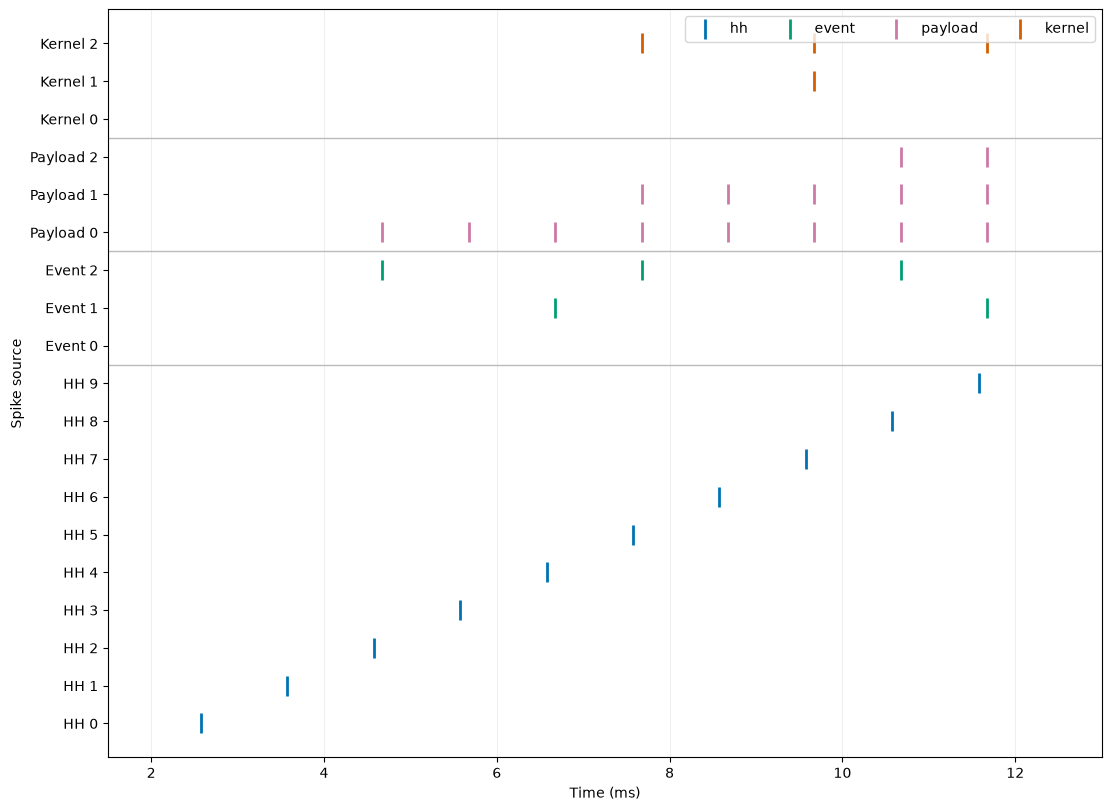

In [6]:
population_order = ("hh", "event", "payload", "kernel")
population_offsets = {
    "hh": 0,
    "event": HH_SIZE,
    "payload": HH_SIZE + REDUCTION_SIZE,
    "kernel": HH_SIZE + 2 * REDUCTION_SIZE,
}
population_colors = {
    "hh": "#0072B2", "event": "#009E73",
    "payload": "#CC79A7", "kernel": "#D55E00"
}
fig, axis = plt.subplots(figsize=(11, 8), constrained_layout=True)
for population_name in population_order:
    frame = spike_table[spike_table["population"] == population_name]
    axis.scatter(
        frame["time_ms"],
        frame["source_id"] + population_offsets[population_name],
        marker="|", s=190, linewidths=2,
        color=population_colors[population_name], label=population_name,
    )
source_labels = (
    [f"HH {member}" for member in range(HH_SIZE)]
    + [f"Event {member}" for member in range(REDUCTION_SIZE)]
    + [f"Payload {member}" for member in range(REDUCTION_SIZE)]
    + [f"Kernel {member}" for member in range(REDUCTION_SIZE)]
)
axis.set_yticks(np.arange(HH_SIZE + 3 * REDUCTION_SIZE), source_labels)
for boundary in (HH_SIZE, HH_SIZE + REDUCTION_SIZE, HH_SIZE + 2 * REDUCTION_SIZE):
    axis.axhline(boundary - 0.5, color="#BBBBBB", linewidth=1)
axis.set_ylabel("Spike source")
axis.set_xlabel("Time (ms)")
axis.set_xlim(1.5, 13.0)
axis.grid(axis="x", alpha=0.2)
axis.legend(ncols=4, loc="upper right")
plt.show()

## What the outputs mean

- Event accumulator 的输入始终是 6，与 connection weight、synapse 类型和 tau 无关。
- Payload accumulator 的输入是 `6 × source weight`，能保留多个 connection 聚合后的幅值，但仍不读取 synapse metadata。
- Kernel accumulator 把每个 payload 乘以静态 kernel 面积。其 `uS·ms` 输出是积分 conductance，不是膜电压或电流。
- HH spike 经过 `0.1 ms` delay 后进入 reduction Cell；所有下游继续发布统一的 `event_outputs["spike"]`。